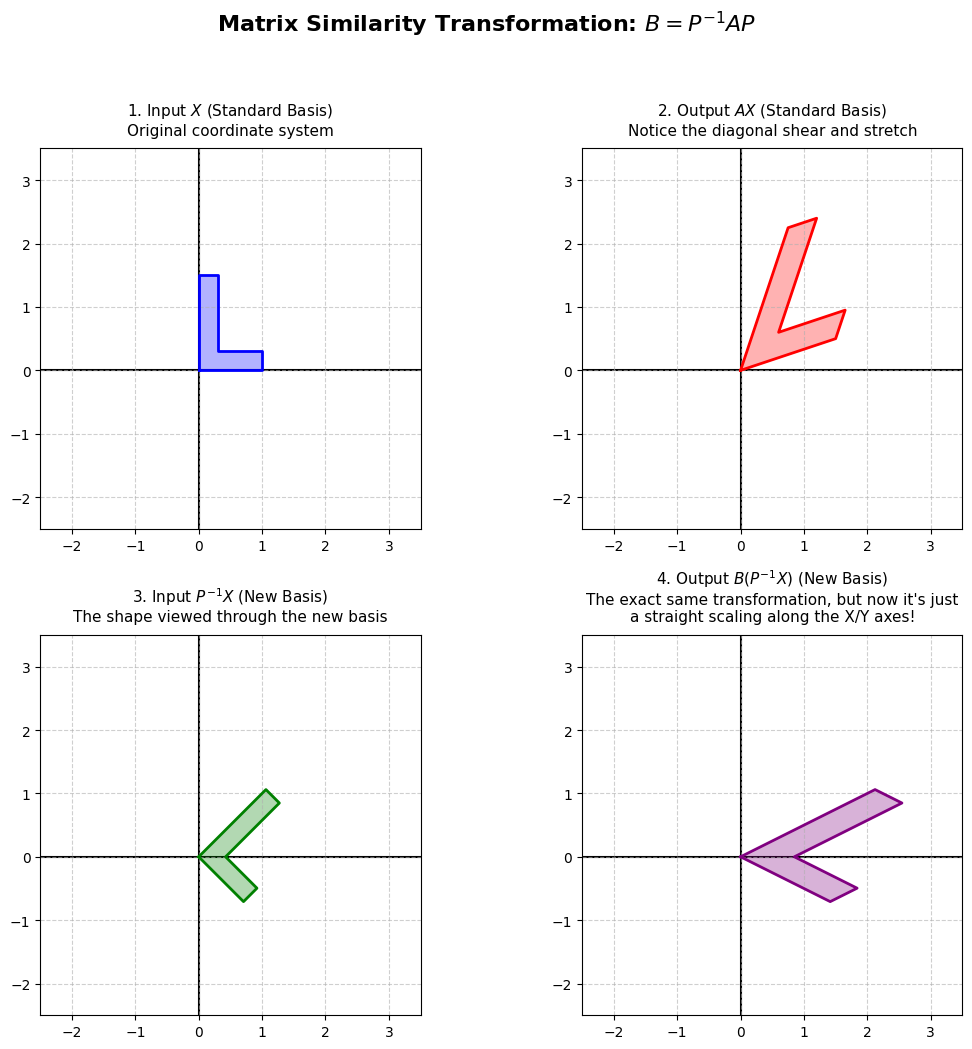

Matrix A:
[[1.5 0.5]
 [0.5 1.5]]

Matrix B (P^-1 A P):
[[2. 0.]
 [0. 1.]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Matrices ---
# A: The original transformation (e.g., a stretch + shear)
A = np.array([[1.5, 0.5],
              [0.5, 1.5]])

# P: The change-of-basis matrix. 
# We use A's eigenvectors here to show the most famous kind of similarity transform (diagonalization).
# NOTE: To test "all kinds", replace P with ANY invertible 2x2 matrix! 
# Example (Rotation): 
# theta = np.radians(45)
# P = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
eigenvalues, P = np.linalg.eig(A)
P_inv = np.linalg.inv(P)

# B: The transformation from the perspective of the new basis
# B = P^-1 * A * P
B = np.round(P_inv @ A @ P, decimals=5)

# --- 2. Define a test shape (an asymmetrical 'L') ---
# Each column is a 2D point [x, y]. We use an asymmetrical shape so 
# rotations, shears, and flips are visually obvious.
shape = np.array([
    [0, 1, 1, 0.3, 0.3, 0, 0],
    [0, 0, 0.3, 0.3, 1.5, 1.5, 0]
])

# --- 3. Compute Transformations ---
# Top Row: The Standard Perspective
shape_A = A @ shape

# Bottom Row: The New Basis Perspective
shape_P_inv = P_inv @ shape
shape_B = B @ shape_P_inv  # Applying B in the new basis!

# --- 4. Visualization Setup ---
fig, axs = plt.subplots(2, 2, figsize=(11, 11))
fig.suptitle("Matrix Similarity Transformation: $B = P^{-1}AP$", fontsize=16, fontweight='bold')

def plot_shape(ax, data, title, color):
    """Helper function to draw the polygon and format the grid."""
    # Draw shape outline and fill
    ax.plot(data[0, :], data[1, :], color=color, lw=2)
    ax.fill(data[0, :], data[1, :], color=color, alpha=0.3)
    
    # Draw axes and grid
    ax.axhline(0, color='black', lw=1.5, zorder=0)
    ax.axvline(0, color='black', lw=1.5, zorder=0)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Keep the aspect ratio square so stretching is accurate
    ax.set_aspect('equal')
    ax.set_xlim(-2.5, 3.5)
    ax.set_ylim(-2.5, 3.5)
    ax.set_title(title, fontsize=11, pad=10)

# Panel 1: Original shape
plot_shape(axs[0, 0], shape, 
           "1. Input $X$ (Standard Basis)\nOriginal coordinate system", 
           'blue')

# Panel 2: Shape transformed by A
plot_shape(axs[0, 1], shape_A, 
           "2. Output $AX$ (Standard Basis)\nNotice the diagonal shear and stretch", 
           'red')

# Panel 3: Original shape translated to the new basis P
plot_shape(axs[1, 0], shape_P_inv, 
           "3. Input $P^{-1}X$ (New Basis)\nThe shape viewed through the new basis", 
           'green')

# Panel 4: Shape transformed by B in the new basis
plot_shape(axs[1, 1], shape_B, 
           "4. Output $B(P^{-1}X)$ (New Basis)\nThe exact same transformation, but now it's just\na straight scaling along the X/Y axes!", 
           'purple')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"Matrix A:\n{A}\n")
print(f"Matrix B (P^-1 A P):\n{B}")

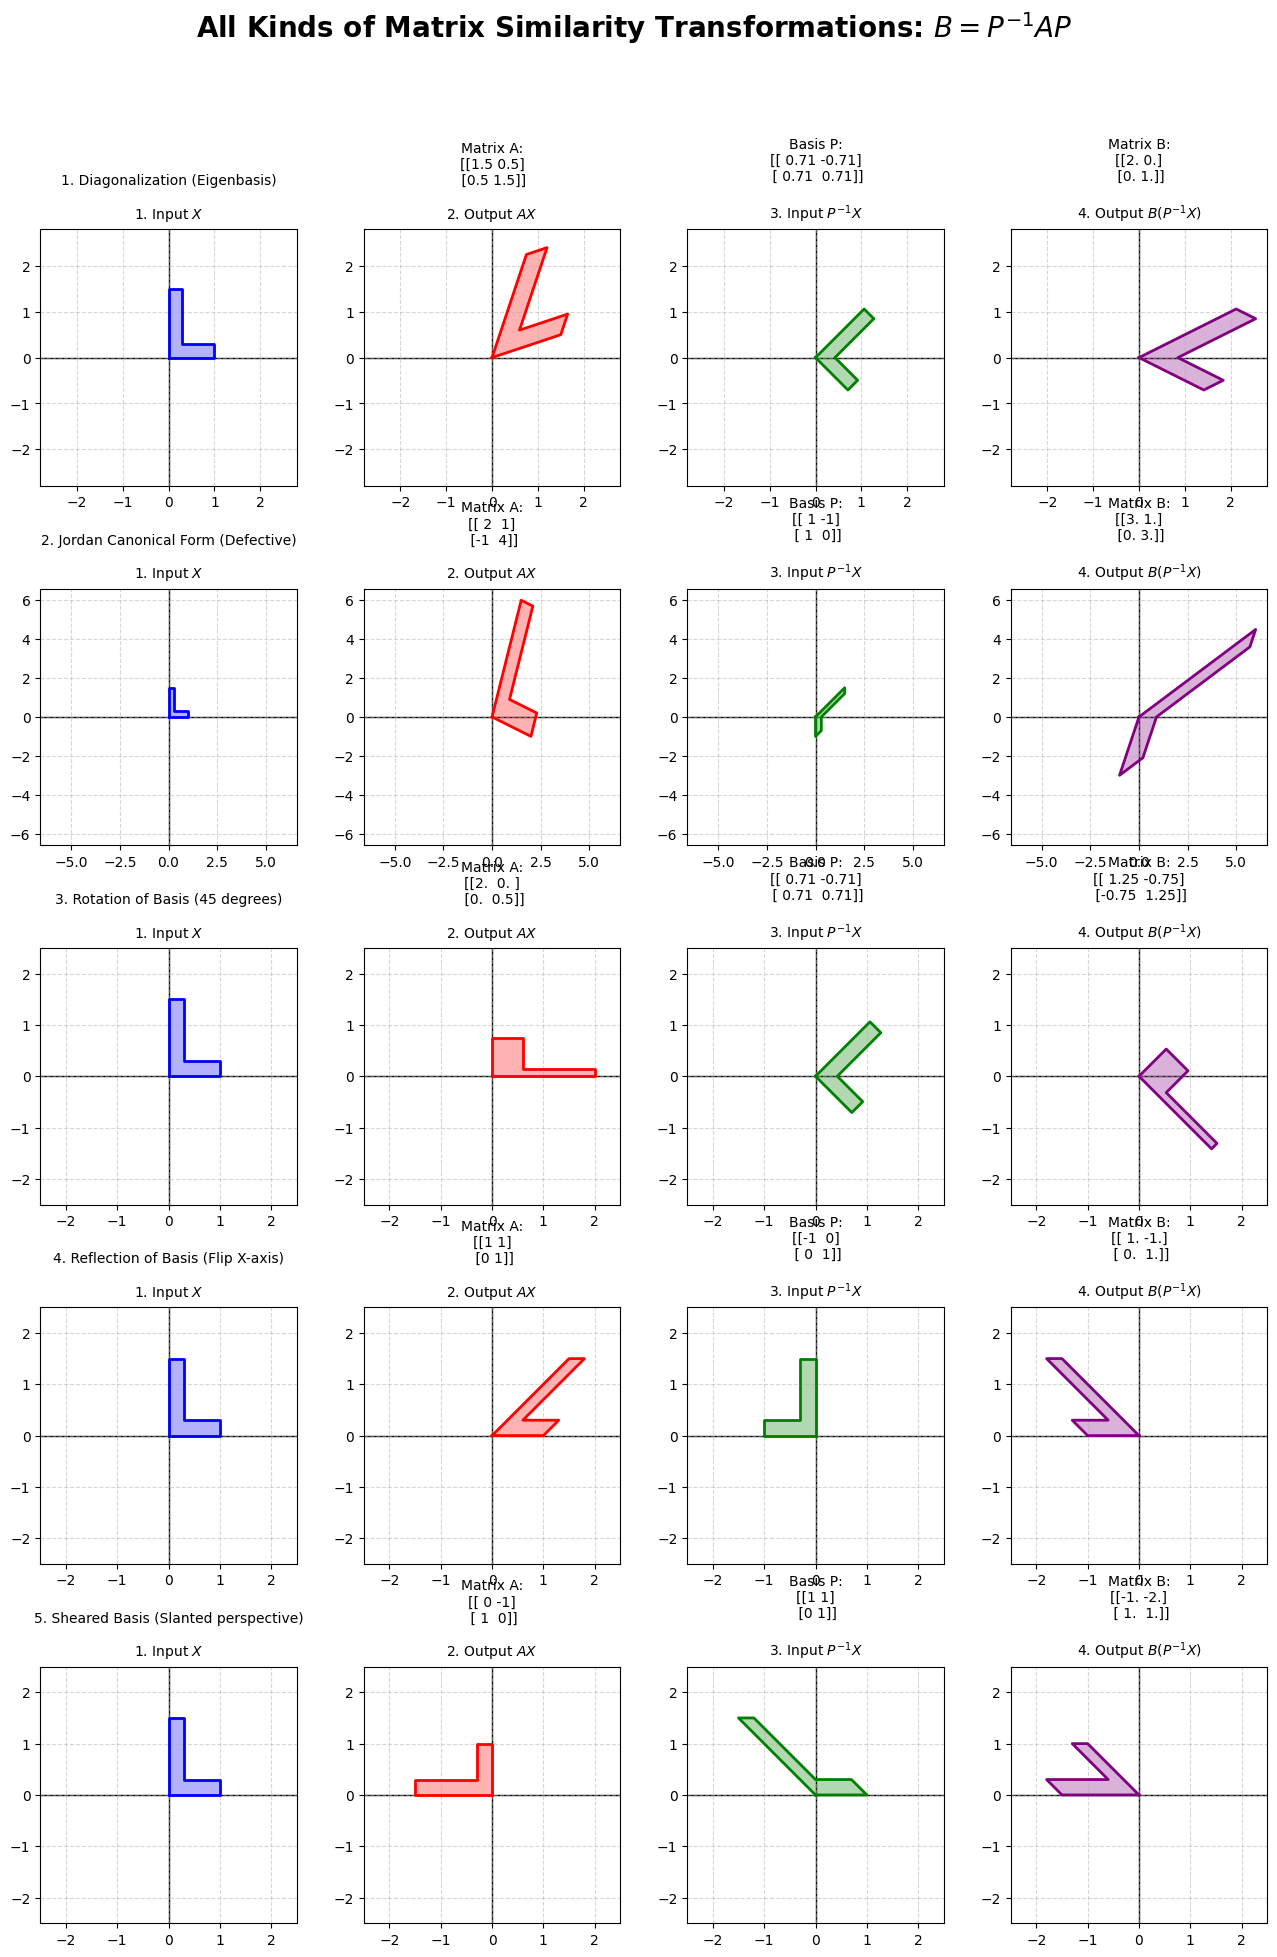

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_step(ax, data, title, color, lim):
    """Helper to draw the polygon and format the grid uniformly."""
    ax.plot(data[0, :], data[1, :], color=color, lw=2)
    ax.fill(data[0, :], data[1, :], color=color, alpha=0.3)
    
    ax.axhline(0, color='black', lw=1, zorder=0)
    ax.axvline(0, color='black', lw=1, zorder=0)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(title, fontsize=10, pad=8)

# --- 1. Define a highly asymmetrical shape (an 'L') ---
# Asymmetry is crucial to clearly see rotations, flips, and shears.
shape = np.array([
    [0, 1, 1, 0.3, 0.3, 0, 0],
    [0, 0, 0.3, 0.3, 1.5, 1.5, 0]
])

# --- 2. Define the 5 Categories of Similarity Transformations ---
transformations = []

# Type 1: Diagonalization (Finding the perfect scaling basis)
A1 = np.array([[1.5, 0.5], [0.5, 1.5]])
_, P1 = np.linalg.eig(A1)
transformations.append(("1. Diagonalization (Eigenbasis)", A1, P1))

# Type 2: Jordan Canonical Form (Defective matrix)
# A2 has eigenvalue 3 (multiplicity 2), but only one eigenvector.
A2 = np.array([[2, 1], [-1, 4]])
# P2 is built from the one eigenvector and one generalized eigenvector
P2 = np.array([[1, -1], [1, 0]]) 
transformations.append(("2. Jordan Canonical Form (Defective)", A2, P2))

# Type 3: Rotation of Basis
A3 = np.array([[2, 0], [0, 0.5]]) # Pure stretch in standard basis
theta = np.radians(45)
P3 = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
transformations.append(("3. Rotation of Basis (45 degrees)", A3, P3))

# Type 4: Reflection of Basis
A4 = np.array([[1, 1], [0, 1]]) # Horizontal shear
P4 = np.array([[-1, 0], [0, 1]]) # Flip the X axis
transformations.append(("4. Reflection of Basis (Flip X-axis)", A4, P4))

# Type 5: Skewed/Sheared Basis
A5 = np.array([[0, -1], [1, 0]]) # Pure 90-degree rotation
P5 = np.array([[1, 1], [0, 1]]) # Slanted/Sheared coordinate system
transformations.append(("5. Sheared Basis (Slanted perspective)", A5, P5))


# --- 3. Generate the 5x4 Grid Visualization ---
fig, axs = plt.subplots(5, 4, figsize=(16, 22))
fig.suptitle("All Kinds of Matrix Similarity Transformations: $B = P^{-1}AP$", 
             fontsize=20, fontweight='bold', y=0.98)

# Adjust spacing between rows and columns
fig.subplots_adjust(hspace=0.4, wspace=0.2)

for i, (name, A, P) in enumerate(transformations):
    # Calculate Similarity Transform components
    P_inv = np.linalg.inv(P)
    B = P_inv @ A @ P
    
    # Calculate the 4 coordinate states
    X = shape
    AX = A @ X
    P_inv_X = P_inv @ X
    B_P_inv_X = B @ P_inv_X
    
    # Determine uniform axis limits for this specific row
    max_val = max(np.max(np.abs(X)), np.max(np.abs(AX)), 
                  np.max(np.abs(P_inv_X)), np.max(np.abs(B_P_inv_X)))
    lim = max(2.5, max_val * 1.1)
    
    # Column 1: Standard Input
    plot_step(axs[i, 0], X, 
              f"{name}\n\n1. Input $X$", 'blue', lim)
    
    # Column 2: Standard Output
    plot_step(axs[i, 1], AX, 
              f"Matrix A:\n{np.round(A, 2)}\n\n2. Output $AX$", 'red', lim)
    
    # Column 3: Input mapped to new basis
    plot_step(axs[i, 2], P_inv_X, 
              f"Basis P:\n{np.round(P, 2)}\n\n3. Input $P^{{-1}}X$", 'green', lim)
    
    # Column 4: Output mapped to new basis
    plot_step(axs[i, 3], B_P_inv_X, 
              f"Matrix B:\n{np.round(B, 2)}\n\n4. Output $B(P^{{-1}}X)$", 'purple', lim)

# Save high-res image and display
plt.savefig("similarity_transformations_master.png", dpi=150, bbox_inches='tight')
plt.show()